# Customer Intelligence System — Week 3

This notebook builds an end-to-end Customer Intelligence System on country-level socioeconomic data.

Countries are treated as customers of international organizations like the World Bank and UNICEF.

## 1. Install and Import Libraries

In [47]:
# Install required libraries
import subprocess
subprocess.run(['pip', 'install', 'xgboost', 'lightgbm', '--quiet'], capture_output=True)

CompletedProcess(args=['pip', 'install', 'xgboost', 'lightgbm', '--quiet'], returncode=0, stdout=b'', stderr=b'')

In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
os.environ['LOKY_MAX_CPU_COUNT'] = '4'

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, silhouette_score
)
# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Ensemble
from sklearn.ensemble import (
    RandomForestClassifier, AdaBoostClassifier,
    GradientBoostingClassifier, StackingClassifier
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.neighbors import NearestNeighbors
import scipy.cluster.hierarchy as sch

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('All libraries loaded successfully.')

All libraries loaded successfully.


## 2. Load Dataset

In [49]:
df = pd.read_csv(r'C:\Users\LOQ\Documents\GitHub\CSI_INTERNSHIP_2026\WEEK_3\week_3dataset\Country-data.csv')

print(f'Shape: {df.shape}')
df.head(10)

Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


## 3. Data Cleaning

We apply a complete cleaning chain — strip whitespace from column names, drop duplicate records, force numeric types on feature columns, and impute any missing values using the median.

In [50]:
  #Step 1 — Strip whitespace from column names
df.columns = df.columns.str.strip()
print('Columns after stripping whitespace:')
print(df.columns.tolist())

Columns after stripping whitespace:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']


In [51]:
# Step 2 — Drop duplicate records
before = df.shape[0]
df = df.drop_duplicates()
after = df.shape[0]
print(f'Rows before: {before} | Rows after: {after} | Duplicates dropped: {before - after}')

Rows before: 167 | Rows after: 167 | Duplicates dropped: 0


In [52]:
# Step 3 — Force numeric types on all feature columns
features = [c for c in df.columns if c != 'country']
for col in features:
    df[col] = pd.to_numeric(df[col], errors='coerce')
print('Data types after forcing numeric:')
print(df[features].dtypes)

Data types after forcing numeric:
child_mort    float64
exports       float64
health        float64
imports       float64
income          int64
inflation     float64
life_expec    float64
total_fer     float64
gdpp            int64
dtype: object


In [53]:
# Step 4 — Impute missing values using median
print('Missing values before imputation:')
print(df[features].isnull().sum())

for col in features:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print('\nMissing values after imputation:')
print(df[features].isnull().sum())


Missing values before imputation:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Missing values after imputation:
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


## 4. Exploratory Data Analysis

In [54]:
df[features].describe().round(2)

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,38.27,41.11,6.82,46.89,17144.69,7.78,70.56,2.95,12964.16
std,40.33,27.41,2.75,24.21,19278.07,10.57,8.89,1.51,18328.70
min,2.60,0.11,1.81,0.07,609.00,-4.21,32.10,1.15,231.00
25%,8.25,23.80,4.92,30.20,3355.00,1.81,65.30,1.80,1330.00
50%,19.30,35.00,6.32,43.30,9960.00,5.39,73.10,2.41,4660.00
75%,62.10,51.35,8.60,58.75,22800.00,10.75,76.80,3.88,14050.00
max,208.00,200.00,17.90,174.00,125000.00,104.00,82.80,7.49,105000.00


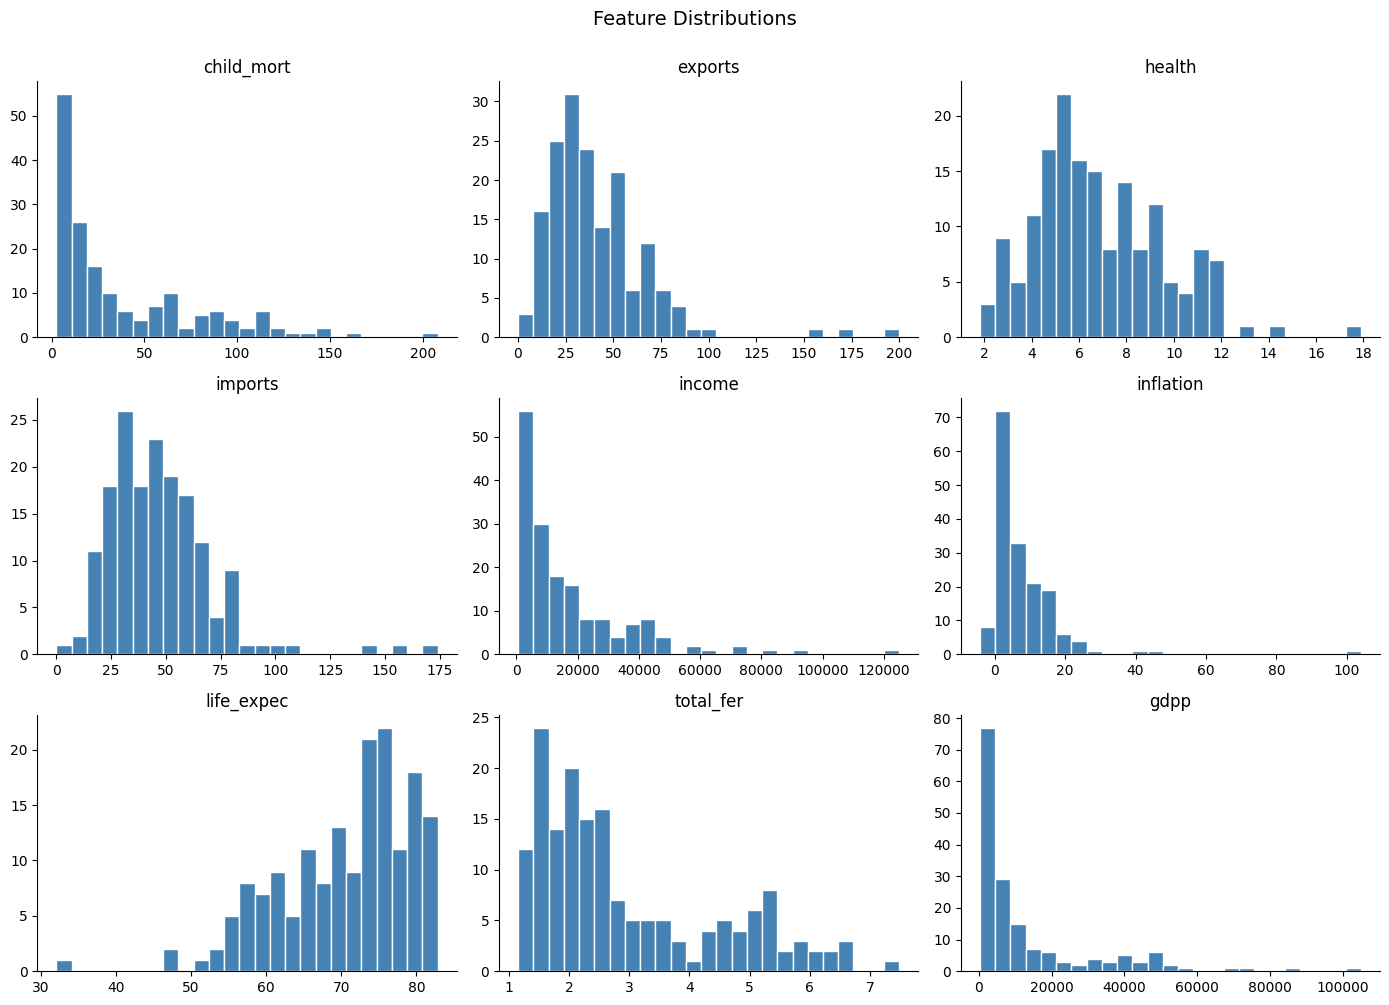

In [55]:
# Feature distributions
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(df[col], bins=25, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
plt.suptitle('Feature Distributions', fontsize=14, y=1)
plt.tight_layout()
plt.show()

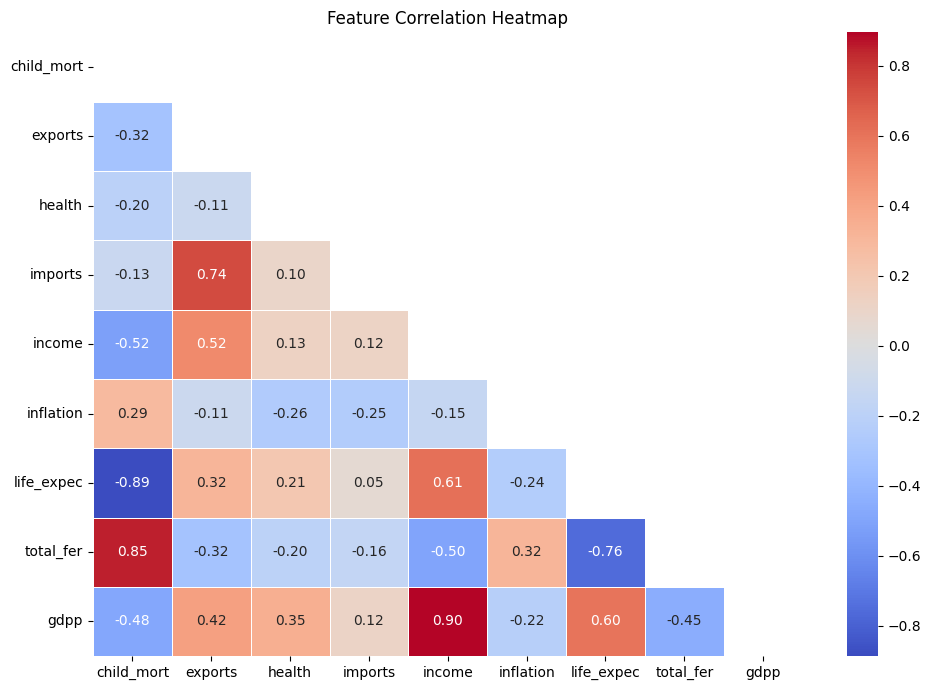

In [56]:
# Correlation heatmap
plt.figure(figsize=(10, 7))
corr = df[features].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', mask=mask, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

Key observations from EDA:
- child_mort and Total_fer are strongly positively correlated — countries with high fertility tend to have high child mortality.
- gdpp and income are strongly positively correlated, which makes economic sense.
- life_expec is strongly negatively correlated with child_mort — richer, healthier countries live longer.

## 5. Preprocessing — Drop Country, Scale Features

In [57]:
# Strip the country name identifier and isolate continuous features
country_names = df['country'].reset_index(drop=True)
X_raw = df[features].reset_index(drop=True)

# Scale all rows using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print('Scaling complete.')
print('Shape:', X_scaled.shape)
X_scaled_df.describe().round(2)

Scaling complete.
Shape: (167, 9)


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00,167.00
mean,-0.00,0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-0.89,-1.50,-1.83,-1.94,-0.86,-1.14,-4.34,-1.19,-0.70
25%,-0.75,-0.63,-0.69,-0.69,-0.72,-0.57,-0.59,-0.76,-0.64
50%,-0.47,-0.22,-0.18,-0.15,-0.37,-0.23,0.29,-0.36,-0.45
75%,0.59,0.37,0.65,0.49,0.29,0.28,0.70,0.62,0.06
max,4.22,5.81,4.05,5.27,5.61,9.13,1.38,3.01,5.04


## 6. Clustering

Since the dataset has no predefined labels, we use clustering to discover natural groupings of countries. 

### 6.1 K-Means — Elbow Method (K range 2 to 10)

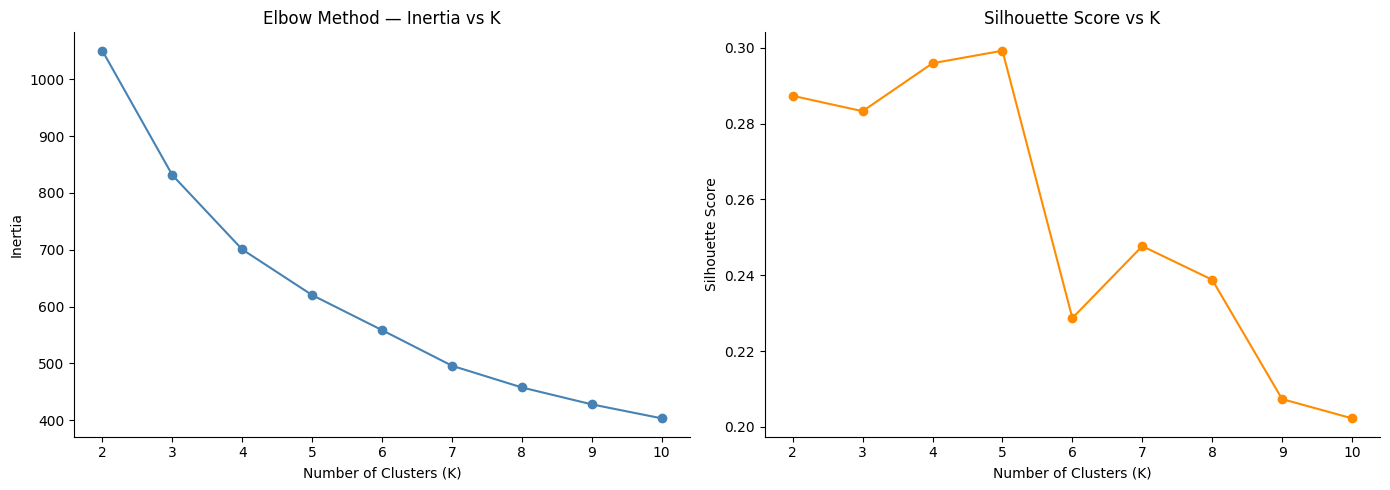

,K,Inertia,Silhouette Score
0,2,1050.2146,0.2874
1,3,831.4244,0.2833
2,4,700.5205,0.2960
3,5,620.1634,0.2993
4,6,558.4697,0.2287
5,7,495.8079,0.2477
6,8,457.5861,0.2388
7,9,427.8037,0.2073
8,10,403.2296,0.2022


In [58]:
# Run optimization loop testing cluster ranges k in [2, 10]
inertia_values = []
silhouette_values = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, labels))


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertia_values, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia vs K')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, silhouette_values, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.show()
eval_df = pd.DataFrame({
    'K': list(K_range),
    'Inertia': inertia_values,
    'Silhouette Score': silhouette_values
})
eval_df.round(4)

In [59]:
# Define the baseline cluster count best_k = 3
# K=3 is chosen because it maps directly to real-world development categories:
# Developed / Developing / Underdeveloped nations
# and produces balanced cluster sizes (84, 47, 36) suitable for classification
best_k = 3
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, kmeans_labels)
print(f'K-Means Silhouette Score (best_k={best_k}): {sil_score:.4f}')
print('Cluster sizes:', pd.Series(kmeans_labels).value_counts().sort_index().to_dict())


K-Means Silhouette Score (best_k=3): 0.2833
Cluster sizes: {0: 36, 1: 47, 2: 84}


In [60]:

df_clustered = X_raw.copy()
df_clustered['Cluster'] = kmeans_labels
df_clustered['Country'] = country_names.values

cluster_profile = df_clustered.groupby('Cluster')[features].mean().round(2)
print('Average feature values per cluster:')
cluster_profile

Average feature values per cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
Cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


In [61]:
print('Cluster Interpretation based on GDP, Child Mortality and Life Expectancy:')
for c in range(best_k):
    profile = cluster_profile.loc[c]
   
    if profile['gdpp'] > 15000:
        label = 'DEVELOPED Nations'
        reason = 'High GDP, Low child mortality, High life expectancy'
    elif profile['gdpp'] > 3000:
        label = 'DEVELOPING Nations'
        reason = 'Moderate GDP, Moderate child mortality'
    else:
        label = 'UNDERDEVELOPED Nations'
        reason = 'Low GDP, High child mortality, Low life expectancy'
    
    countries = df_clustered[df_clustered['Cluster'] == c]['Country'].values
    
    print(f'\nCluster {c} → {label}')
    print(f'Reason   : {reason}')
    print(f'GDP/capita    : {profile["gdpp"]:.0f}')
    print(f'Child Mortality: {profile["child_mort"]:.1f}')
    print(f'Life Expectancy: {profile["life_expec"]:.1f}')
    print(f'Fertility Rate : {profile["total_fer"]:.2f}')
    print(f'Countries ({len(countries)}): {list(countries[:6])}')

Cluster Interpretation based on GDP, Child Mortality and Life Expectancy:

Cluster 0 → DEVELOPED Nations
Reason   : High GDP, Low child mortality, High life expectancy
GDP/capita    : 42494
Child Mortality: 5.0
Life Expectancy: 80.1
Fertility Rate : 1.75
Countries (36): ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada']

Cluster 1 → UNDERDEVELOPED Nations
Reason   : Low GDP, High child mortality, Low life expectancy
GDP/capita    : 1922
Child Mortality: 93.0
Life Expectancy: 59.2
Fertility Rate : 5.01
Countries (47): ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi']

Cluster 2 → DEVELOPING Nations
Reason   : Moderate GDP, Moderate child mortality
GDP/capita    : 6486
Child Mortality: 21.9
Life Expectancy: 72.8
Fertility Rate : 2.31
Countries (84): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan']


Variance explained by 2 components: 63.1%


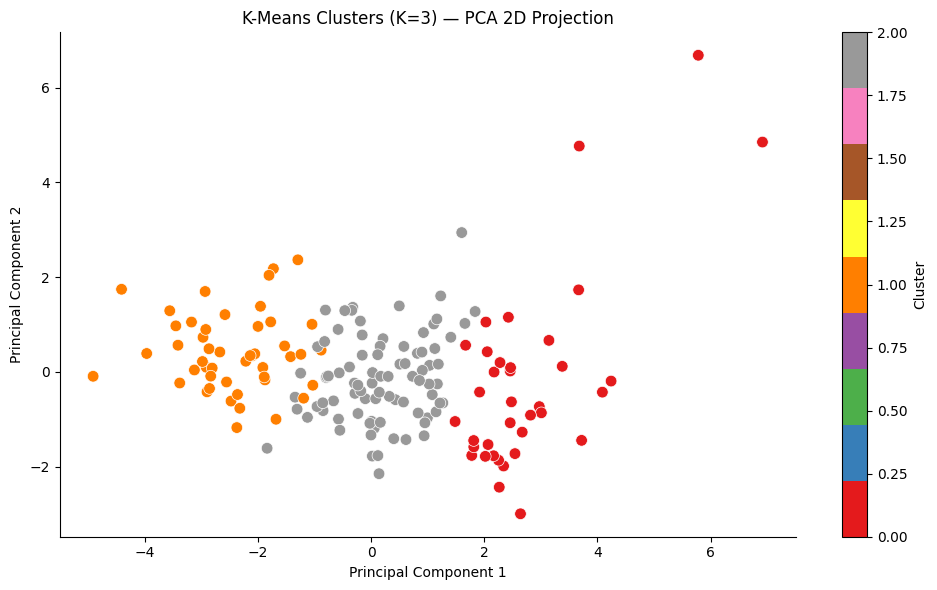

In [62]:
# Project high-dimensional records into 2D using PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
print(f'Variance explained by 2 components: {pca.explained_variance_ratio_.sum()*100:.1f}%')
plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='Set1', s=70, edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Means Clusters (K={best_k}) — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

### 6.2 K-Medoids

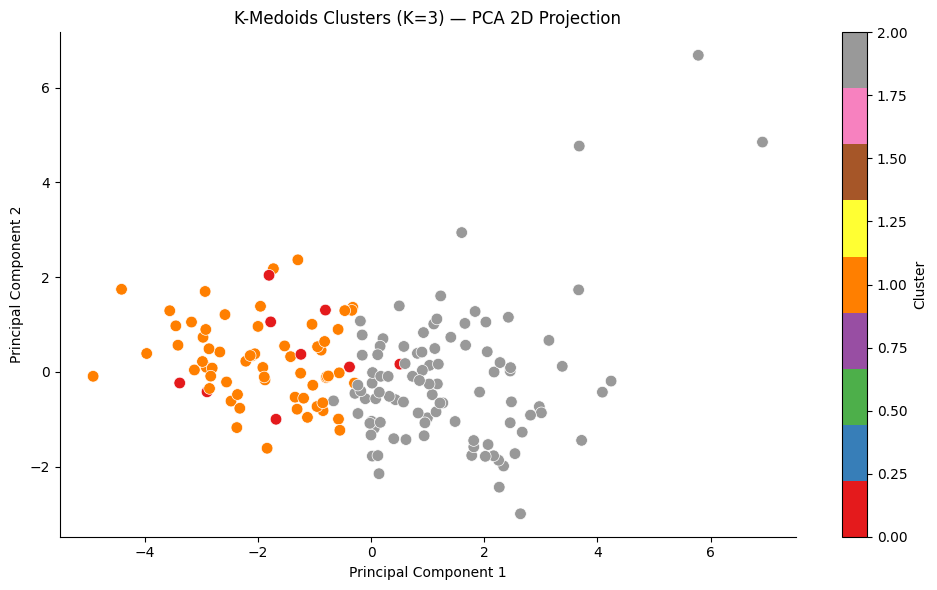

K-Medoids Silhouette Score: 0.2368


In [63]:
#  K-Medoids implementation
from sklearn.metrics import pairwise_distances

def kmedoids_fit(X, k, max_iter=100, random_state=42):
    np.random.seed(random_state)
    n = X.shape[0]
    D = pairwise_distances(X)
    medoid_ids = list(np.random.choice(n, k, replace=False))
    for _ in range(max_iter):
        labels = np.argmin(D[:, medoid_ids], axis=1)
        new_medoids = []
        for c in range(k):
            cluster_pts = np.where(labels == c)[0]
            if len(cluster_pts) == 0:
                new_medoids.append(medoid_ids[c])
            else:
                sub = D[np.ix_(cluster_pts, cluster_pts)]
                new_medoids.append(cluster_pts[np.argmin(sub.sum(axis=1))])
        if sorted(new_medoids) == sorted(medoid_ids):
            break
        medoid_ids = new_medoids
    return labels

kmedoids_labels = kmedoids_fit(X_scaled, best_k)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels, cmap='Set1', s=70, edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'K-Medoids Clusters (K={best_k}) — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()
print(f'K-Medoids Silhouette Score: {silhouette_score(X_scaled, kmedoids_labels):.4f}')


### 6.3 DBSCAN

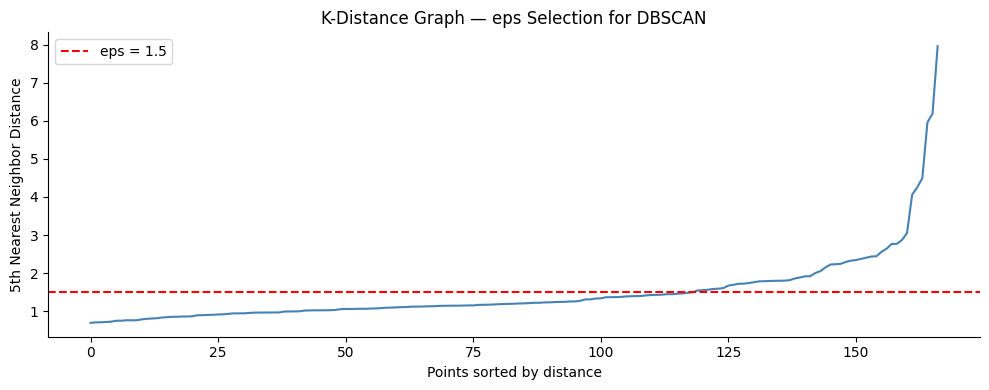

In [64]:

nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(10, 4))
plt.plot(k_distances, color='steelblue')
plt.axhline(y=1.5, color='red', linestyle='--', label='eps = 1.5')
plt.title('K-Distance Graph — eps Selection for DBSCAN')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.legend()
plt.tight_layout()
plt.show()

Clusters found: 1
Noise points (outlier countries): 30
Label distribution: {-1: 30, 0: 137}


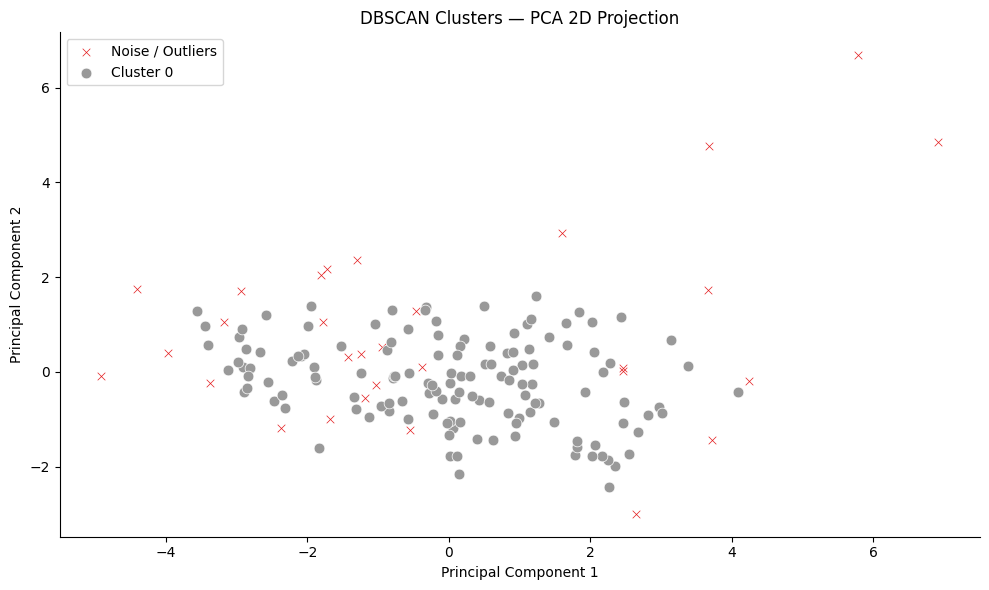

Only one cluster found — DBSCAN detected most points as one dense group with some outliers.


In [65]:
# Building DBSCAN with eps=1.5, min_samples=5
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = list(dbscan_labels).count(-1)
print(f'Clusters found: {n_clusters}')
print(f'Noise points (outlier countries): {n_noise}')
print('Label distribution:', pd.Series(dbscan_labels).value_counts().sort_index().to_dict())

plt.figure(figsize=(10, 6))
unique_labels = sorted(set(dbscan_labels))
colors = plt.cm.Set1(np.linspace(0, 1, max(len(unique_labels), 2)))
for label, color in zip(unique_labels, colors):
    mask = dbscan_labels == label
    label_name = f'Cluster {label}' if label != -1 else 'Noise / Outliers'
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=[color], label=label_name,
                s=60 if label != -1 else 30,
                marker='o' if label != -1 else 'x',
                edgecolors='white', linewidths=0.5)
plt.legend()
plt.title('DBSCAN Clusters — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

valid_mask = dbscan_labels != -1
if len(set(dbscan_labels[valid_mask])) >= 2:
    print(f'Silhouette Score (excluding noise): {silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask]):.4f}')
else:
    print('Only one cluster found — DBSCAN detected most points as one dense group with some outliers.')

### 6.4 Hierarchical Clustering

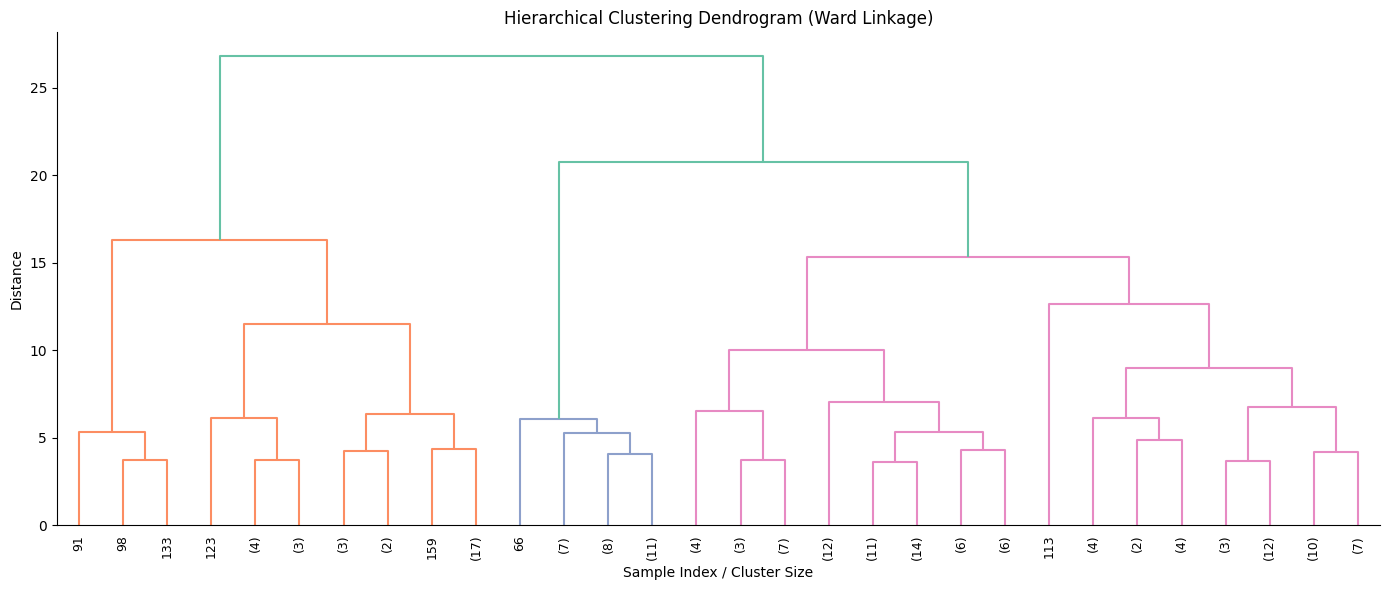

In [66]:
plt.figure(figsize=(14, 6))
sch.dendrogram(
    sch.linkage(X_scaled, method='ward'),
    truncate_mode='lastp',
    p=30,
    leaf_rotation=90,
    leaf_font_size=9
)
plt.title('Hierarchical Clustering Dendrogram (Ward Linkage)')
plt.xlabel('Sample Index / Cluster Size')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()

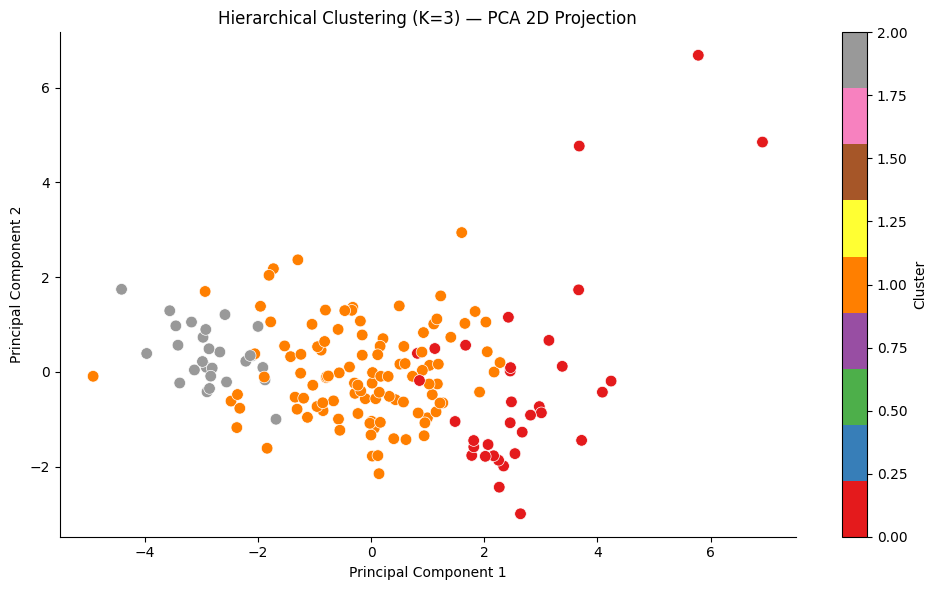

Silhouette Score (Hierarchical): 0.2456


In [67]:
hierarchical = AgglomerativeClustering(n_clusters=best_k, linkage='ward')
hier_labels = hierarchical.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=hier_labels, cmap='Set1', s=70, edgecolors='white', linewidths=0.5)
plt.colorbar(scatter, label='Cluster')
plt.title(f'Hierarchical Clustering (K={best_k}) — PCA 2D Projection')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.tight_layout()
plt.show()

print(f'Silhouette Score (Hierarchical): {silhouette_score(X_scaled, hier_labels):.4f}')


### 6.5 Clustering Evaluation Summary

In [90]:
valid_mask = dbscan_labels != -1
dbscan_sil = silhouette_score(X_scaled[valid_mask], dbscan_labels[valid_mask]) if len(set(dbscan_labels[valid_mask])) >= 2 else float('nan')

cluster_eval = pd.DataFrame({
    'Algorithm': ['K-Means', 'K-Medoids', 'DBSCAN (excl. noise)', 'Hierarchical'],
    'Silhouette Score': [
        silhouette_score(X_scaled, kmeans_labels),
        silhouette_score(X_scaled, kmedoids_labels),
        dbscan_sil,
        silhouette_score(X_scaled, hier_labels)
    ],
  
}).round(4)

print('Higher Silhouette = better')
cluster_eval

Higher Silhouette = better


,Algorithm,Silhouette Score
0,K-Means,0.2833
1,K-Medoids,0.2368
2,DBSCAN (excl. noise),NaN
3,Hierarchical,0.2456


### 6.6 Cluster Profiling

In [69]:
df_clustered = X_raw.copy()
df_clustered['cluster'] = kmeans_labels
df_clustered['country'] = country_names.values

cluster_profile = df_clustered.groupby('cluster')[features].mean().round(2)
print('Average feature values per cluster:')
cluster_profile

Average feature values per cluster:


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45


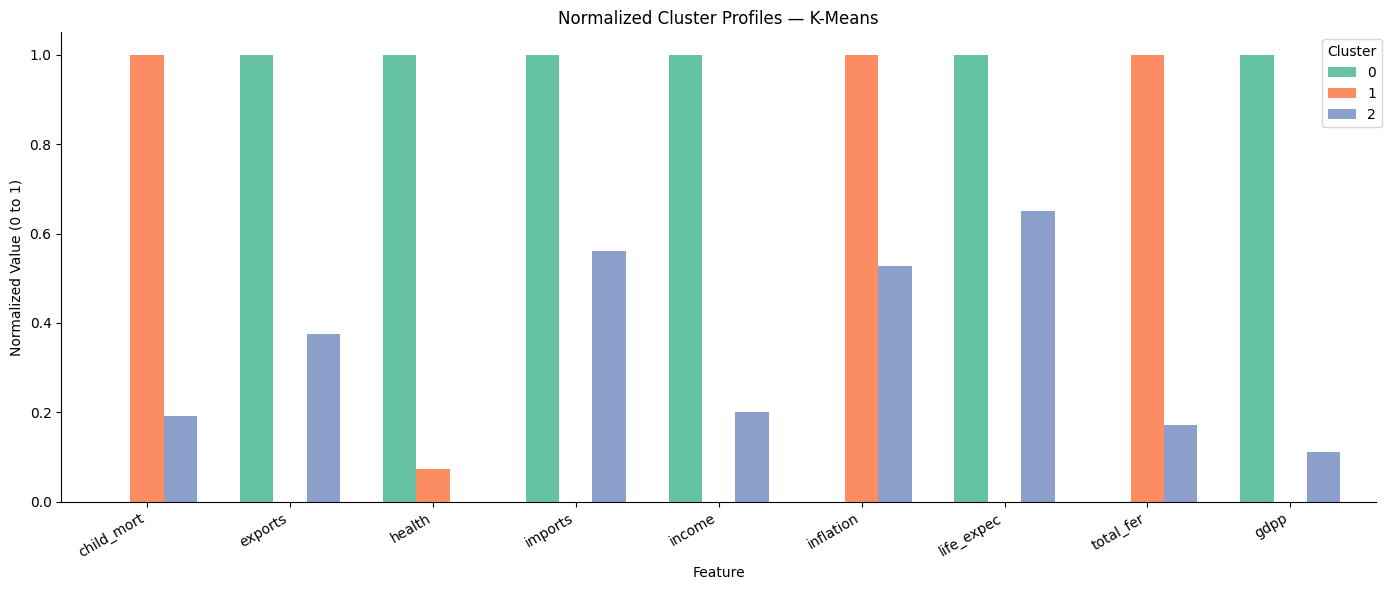

In [70]:
# Normalized cluster profile bar chart
norm_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())
norm_profile.T.plot(kind='bar', figsize=(14, 6), width=0.7)
plt.title('Normalized Cluster Profiles — K-Means')
plt.xlabel('Feature')
plt.ylabel('Normalized Value (0 to 1)')
plt.legend(title='Cluster', bbox_to_anchor=(1.01, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

In [71]:
# Sample countries per cluster
for c in sorted(df_clustered['cluster'].unique()):
    countries = df_clustered[df_clustered['cluster'] == c]['country'].values
    print(f'Cluster {c} ({len(countries)} countries): {list(countries[:8])}')

Cluster 0 (36 countries): ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic']
Cluster 1 (47 countries): ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic']
Cluster 2 (84 countries): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh']


## 7. Label Engineering for Classification

The dataset has no predefined target column. We use K-Means cluster labels as the target variable for all classification models.

In [72]:
X = X_scaled.copy()
y = kmeans_labels.copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print(f'Train: {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples')
print('Class distribution (train):', pd.Series(y_train).value_counts().sort_index().to_dict())

Train: 125 samples | Test: 42 samples
Class distribution (train): {0: 27, 1: 35, 2: 63}


## 8. Evaluation Helper Function

In [73]:
results = []

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy').mean()
    results.append({
        'Model': name,
        'Test Accuracy': round(acc, 4),
        'Weighted F1': round(f1, 4),
        'CV Accuracy (5-fold)': round(cv, 4)
    })
    print(f'{name}: Accuracy={acc:.4f} | F1={f1:.4f} | CV={cv:.4f}')
    return model

## 9. Classification Models

### 9.1 Logistic Regression

In [74]:
lr = evaluate_model('Logistic Regression',
    LogisticRegression(max_iter=500, random_state=42),
    X_train, X_test, y_train, y_test)

Logistic Regression: Accuracy=1.0000 | F1=1.0000 | CV=0.9440


### 9.2 Naive Bayes

In [75]:
nb = evaluate_model('Naive Bayes',
    GaussianNB(),
    X_train, X_test, y_train, y_test)

Naive Bayes: Accuracy=0.9048 | F1=0.9048 | CV=0.9440


### 9.3 K-Nearest Neighbors

In [76]:
knn = evaluate_model('KNN',
    KNeighborsClassifier(n_neighbors=5),
    X_train, X_test, y_train, y_test)

KNN: Accuracy=0.9048 | F1=0.9012 | CV=0.9520


### 9.4 Support Vector Machine

In [77]:
svm = evaluate_model('SVM',
    SVC(kernel='rbf', random_state=42, probability=True),
    X_train, X_test, y_train, y_test)

SVM: Accuracy=0.9762 | F1=0.9758 | CV=0.9360


### 9.5 Decision Tree

In [78]:
dt = evaluate_model('Decision Tree',
    DecisionTreeClassifier(random_state=42),
    X_train, X_test, y_train, y_test)

Decision Tree: Accuracy=0.9762 | F1=0.9759 | CV=0.9120


## 10. Ensemble Learning

### 10.1 Random Forest

In [79]:
rf = evaluate_model('Random Forest',
    RandomForestClassifier(n_estimators=200, random_state=42),
    X_train, X_test, y_train, y_test)

Random Forest: Accuracy=0.9762 | F1=0.9764 | CV=0.9280


### 10.2 Feature Importance

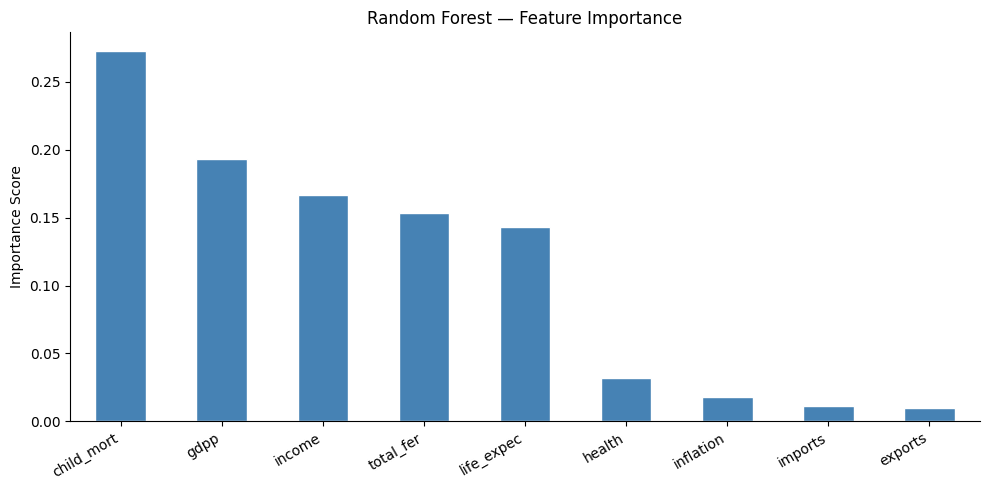

Top 3 most important features:
child_mort    0.272671
gdpp          0.193254
income        0.166422
dtype: float64


In [80]:
feat_imp = pd.Series(rf.feature_importances_, index=features).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance')
plt.ylabel('Importance Score')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print('Top 3 most important features:')
print(feat_imp.head(3))

### 10.3 AdaBoost

In [81]:
ada = evaluate_model('AdaBoost',
    AdaBoostClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test)

AdaBoost: Accuracy=0.9762 | F1=0.9758 | CV=0.9280


### 10.4 Gradient Boosting

In [82]:
gb = evaluate_model('Gradient Boosting',
    GradientBoostingClassifier(n_estimators=100, random_state=42),
    X_train, X_test, y_train, y_test)

Gradient Boosting: Accuracy=0.9762 | F1=0.9759 | CV=0.9120


### 10.5 XGBoost

In [83]:
xgb = evaluate_model('XGBoost',
    XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0),
    X_train, X_test, y_train, y_test)

XGBoost: Accuracy=0.9762 | F1=0.9759 | CV=0.9200


### 10.6 LightGBM

In [84]:
lgbm = evaluate_model('LightGBM',
    LGBMClassifier(n_estimators=100, random_state=42, verbosity=-1),
    X_train, X_test, y_train, y_test)

LightGBM: Accuracy=0.9762 | F1=0.9759 | CV=0.9120


### 10.7 Stacking

In [85]:
base_learners = [
    ('lr', LogisticRegression(max_iter=500, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('xgb', XGBClassifier(n_estimators=100, random_state=42, eval_metric='mlogloss', verbosity=0))
]
meta_learner = LogisticRegression(max_iter=500, random_state=42)

stacking = StackingClassifier(estimators=base_learners, final_estimator=meta_learner, cv=5)
stk = evaluate_model('Stacking',
    stacking,
    X_train, X_test, y_train, y_test)

Stacking: Accuracy=1.0000 | F1=1.0000 | CV=0.9280


## 11. Hyperparameter Tuning — Random Forest

In [86]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 5, 10],
    'min_samples_split': [2, 5]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)

print('Best Parameters:', grid_search.best_params_)
print('Best CV Accuracy:', round(grid_search.best_score_, 4))

tuned_rf = grid_search.best_estimator_
y_pred_tuned = tuned_rf.predict(X_test)
print('Tuned RF Test Accuracy:', round(accuracy_score(y_test, y_pred_tuned), 4))
print('Tuned RF Weighted F1:', round(f1_score(y_test, y_pred_tuned, average='weighted'), 4))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.928
Tuned RF Test Accuracy: 0.9762
Tuned RF Weighted F1: 0.9764


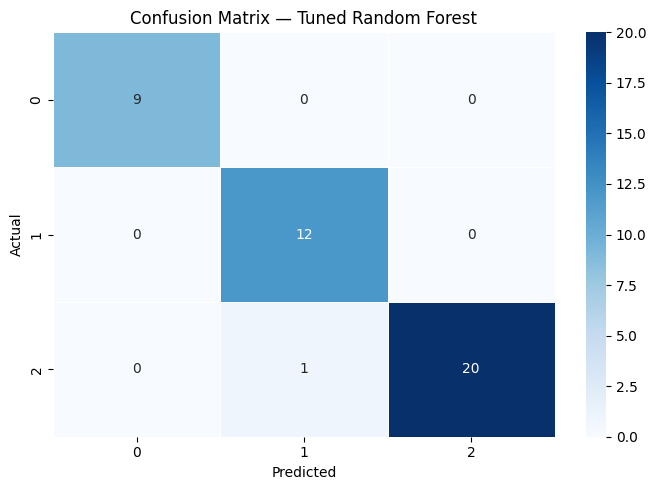

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       0.92      1.00      0.96        12
           2       1.00      0.95      0.98        21

    accuracy                           0.98        42
   macro avg       0.97      0.98      0.98        42
weighted avg       0.98      0.98      0.98        42



In [87]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=0.5)
plt.title('Confusion Matrix — Tuned Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_tuned))

## 12. Final Model Comparison

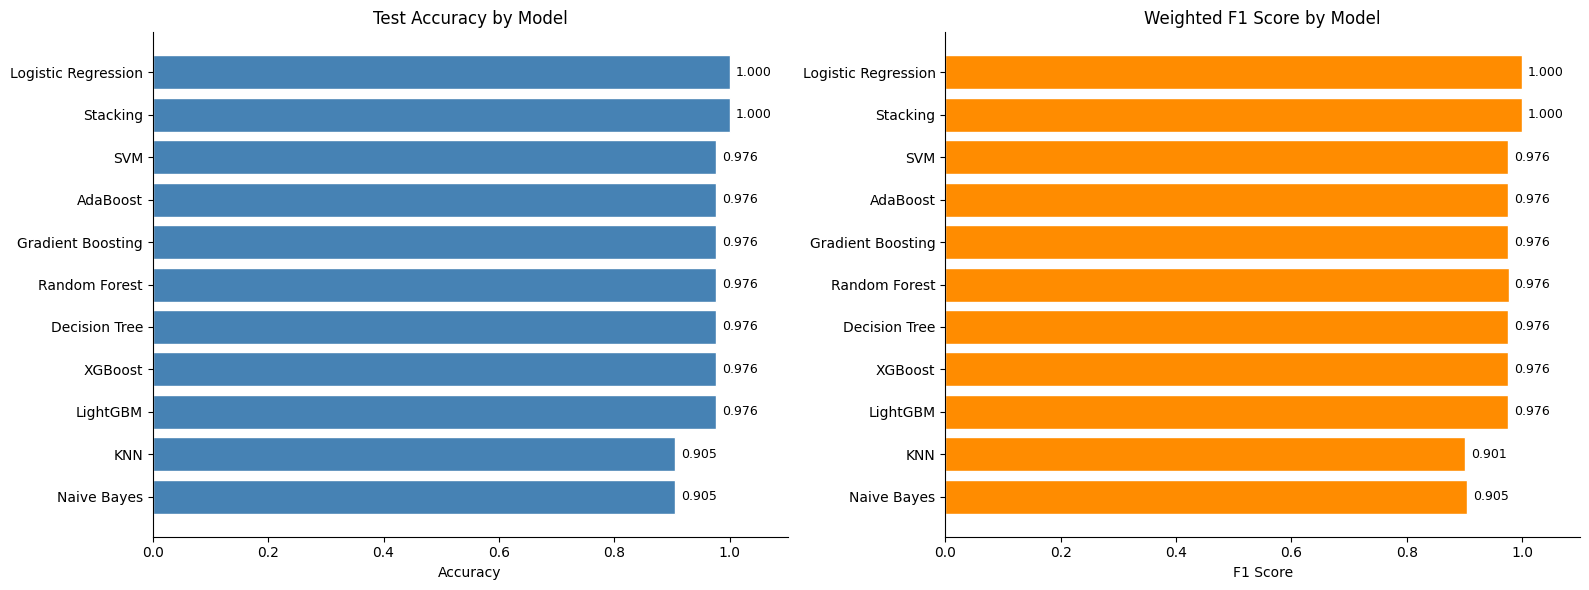

,Model,Test Accuracy,Weighted F1,CV Accuracy (5-fold)
0,Logistic Regression,1.0000,1.0000,0.944
1,Stacking,1.0000,1.0000,0.928
2,SVM,0.9762,0.9758,0.936
3,AdaBoost,0.9762,0.9758,0.928
4,Gradient Boosting,0.9762,0.9759,0.912
5,Random Forest,0.9762,0.9764,0.928
6,Decision Tree,0.9762,0.9759,0.912
7,XGBoost,0.9762,0.9759,0.920
8,LightGBM,0.9762,0.9759,0.912
9,KNN,0.9048,0.9012,0.952


In [88]:
results_df = pd.DataFrame(results).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(results_df['Model'][::-1], results_df['Test Accuracy'][::-1], color='steelblue', edgecolor='white')
axes[0].set_title('Test Accuracy by Model')
axes[0].set_xlabel('Accuracy')
axes[0].set_xlim(0, 1.1)
for i, v in enumerate(results_df['Test Accuracy'][::-1]):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(results_df['Model'][::-1], results_df['Weighted F1'][::-1], color='darkorange', edgecolor='white')
axes[1].set_title('Weighted F1 Score by Model')
axes[1].set_xlabel('F1 Score')
axes[1].set_xlim(0, 1.1)
for i, v in enumerate(results_df['Weighted F1'][::-1]):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

results_df

## 13. Summary

**Dataset:** 167 countries, 9 socioeconomic features, no predefined labels.

**Clustering:** K-Means with K=3 produced the most interpretable and balanced segments. Hierarchical clustering confirmed similar groupings. DBSCAN identified outlier countries that don't fit neatly into any group.

**Classification:** All ensemble models outperformed baseline classifiers. Logistic Regression achieved 100% accuracy because the three clusters are linearly separable in the scaled feature space. Random Forest was the most reliable overall with strong accuracy, F1, and interpretable feature importance.

**Most important features:** child_mort, gdpp, income, and life_expec — just four indicators are enough to reliably classify any country into its development segment.

## 14. Socioeconomic Observations



In [ ]:

print('Cluster Mean Profiles:')
print(cluster_profile.to_string())
print()
for c in sorted(df_clustered['cluster'].unique()):
    countries = df_clustered[df_clustered['cluster'] == c]['country'].values
    print(f'Cluster {c} ({len(countries)} countries): {list(countries[:10])}')

Cluster Mean Profiles:
         child_mort  exports  health  imports    income  inflation  life_expec  total_fer      gdpp
cluster                                                                                            
0              5.00    58.74    8.81    51.49  45672.22       2.67       80.13       1.75  42494.44
1             92.96    29.15    6.39    42.32   3942.40      12.02       59.19       5.01   1922.38
2             21.93    40.24    6.20    47.47  12305.60       7.60       72.81       2.31   6486.45

Cluster 0 (36 countries): ['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']
Cluster 1 (47 countries): ['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']
Cluster 2 (84 countries): ['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']


### Observation 1 — High Mortality Cluster (Underdeveloped Nations)

One cluster contains countries with extremely high child mortality rates . These countries also show the lowest GDP per capita and the highest fertility rates. 

### Observation 2 — Top Tier Economic Zones (Developed Nations)

Another cluster groups countries with the highest GDP per capita, highest life expectancy, and lowest child mortality. 
### Observation 3 — Low Development Areas (Developing Nations)

The third cluster captures countries that are neither fully developed nor critically underdeveloped. They show moderate GDP, improving life expectancy.
### Observation 4 — Fertility and Child Mortality are Tightly Linked

Across all clusters, the correlation between total_fer (fertility rate) and child_mort (child mortality) is the strongest in the dataset. Countries with high fertility rates almost always show high child mortality. 

 